# Ocena treningu RL — Clash Royale PPO

Notebook zbiera statystyki z:
- logów **TensorBoard** (loss, win rate, nagroda, entropia…)
- pliku **evaluations.npz** (okresowa ewaluacja callbacku)
- **meczów na żywo** PPO vs LogicAgent
- **LogicAgent vs RandomBot** (baseline regułowy)

Uruchom komórki po kolei. Przed pierwszym uruchomieniem wykonaj trening: `python train.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Katalog projektu na sys.path (Jupyter czasem importuje stdlib zamiast lokalnych plików)
PROJECT_ROOT = Path.cwd()
for candidate in (PROJECT_ROOT, PROJECT_ROOT / "clash_royale_rl_agent"):
    if (candidate / "rl_statistics.py").is_file():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from rl_statistics import (
    DEFAULT_MODEL_DIR,
    discover_models,
    evaluate_logic_vs_random,
    evaluate_random_baseline,
    evaluate_saved_model,
    load_eval_npz,
    load_tensorboard_scalars,
)
from train import DEFAULT_BEST_PATH

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["font.size"] = 11

EPISODES = 30          # mecze live-eval na model
LOGIC_EPISODES = 50    # mecze LogicAgent vs RandomBot
SEED = 0
MODEL_DIR = DEFAULT_MODEL_DIR
TB_DIR = MODEL_DIR / "tb"
EVAL_DIR = MODEL_DIR / "eval"

print(f"Katalog modeli: {MODEL_DIR.resolve()}")

Katalog modeli: C:\Users\piotr\Desktop\clash_royale_rl_agent\models


## 1. Metryki z TensorBoard

Krzywe uczenia: nagroda, win rate vs LogicAgent, straty (policy / value / entropy), explained variance.

In [2]:
def series_by_tag(scalars, tag: str):
    """Najnowszy run z danym tagiem."""
    matches = [s for s in scalars if s.tag == tag]
    if not matches:
        return None
    return max(matches, key=lambda s: s.steps[-1] if s.steps else -1)


def plot_tag(ax, scalars, tag: str, label: str | None = None, color=None):
    s = series_by_tag(scalars, tag)
    if s is None:
        ax.set_title(f"{label or tag} — brak danych")
        return False
    ax.plot(s.steps, s.values, label=label or tag, linewidth=2, color=color)
    ax.set_title(label or tag)
    ax.set_xlabel("Krok treningu")
    ax.grid(True, alpha=0.3)
    return True


tb_series = load_tensorboard_scalars(TB_DIR)
runs = sorted({s.run for s in tb_series})
tags = sorted({s.tag for s in tb_series})

print(f"Runy TensorBoard: {', '.join(runs) if runs else '(brak)'}")
print(f"Liczba tagów: {len(tags)}")

KEY_TAGS = [
    "rollout/ep_rew_mean",
    "rollout/win_rate_vs_logic",
    "eval/mean_reward",
    "train/policy_gradient_loss",
    "train/value_loss",
    "train/entropy_loss",
    "train/explained_variance",
    "time/fps",
]

rows = []
for tag in KEY_TAGS:
    s = series_by_tag(tb_series, tag)
    if s is None:
        rows.append({"metryka": tag, "punkty": 0, "pierwsza": None, "ostatnia": None, "szczyt": None})
        continue
    rows.append({
        "metryka": tag,
        "punkty": len(s.values),
        "pierwsza": s.values[0],
        "ostatnia": s.values[-1],
        "szczyt": max(s.values),
    })

summary_tb = pd.DataFrame(rows)
display(summary_tb)

Runy TensorBoard: MaskablePPO_1, MaskablePPO_2
Liczba tagów: 13


,metryka,punkty,pierwsza,ostatnia,szczyt
0,rollout/ep_rew_mean,0,NaN,NaN,NaN
1,rollout/win_rate_vs_logic,198,0.250000,0.255000,0.280000
2,eval/mean_reward,40,-0.010076,0.060202,0.128778
3,train/policy_gradient_loss,488,-0.002972,-0.001369,-0.000150
4,train/value_loss,488,0.012351,0.000020,0.012351
5,train/entropy_loss,488,-0.033322,-0.003525,-0.000895
6,train/explained_variance,488,0.545353,0.979104,0.990883
7,time/fps,489,6968.000000,261.000000,6968.000000


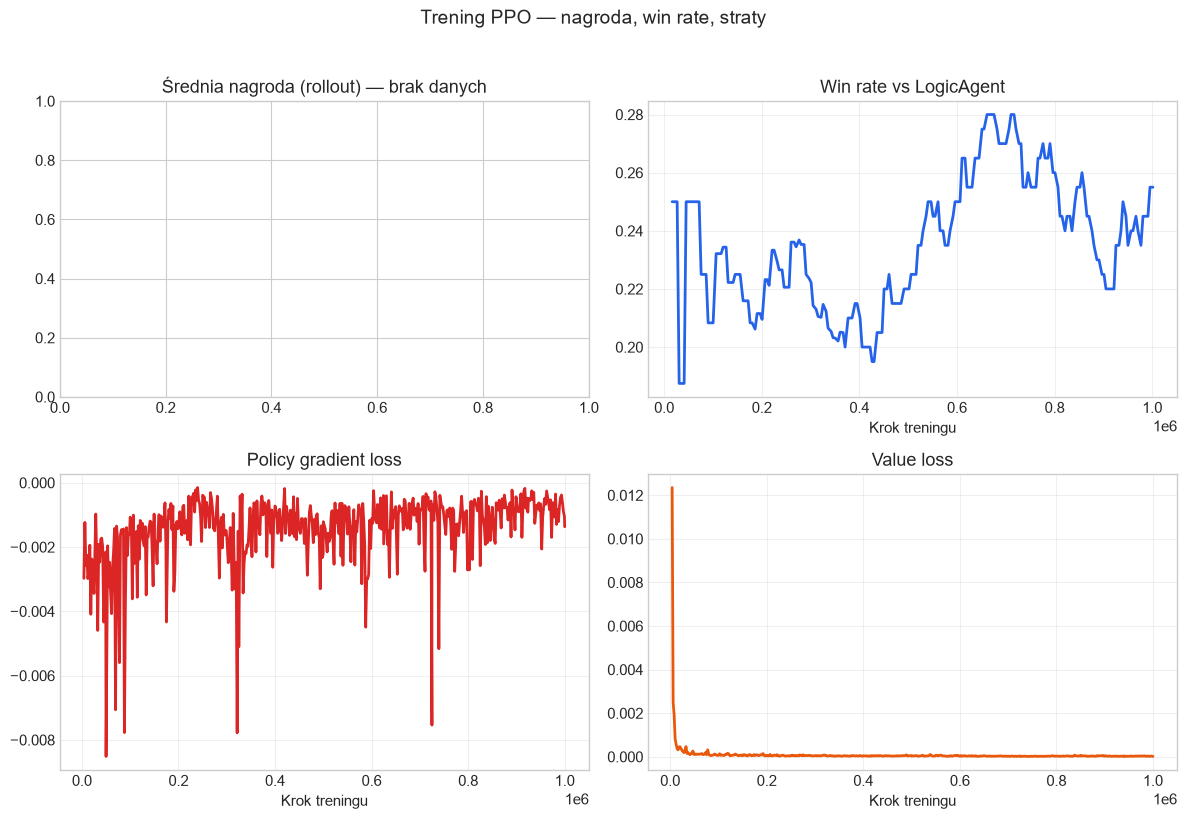

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_tag(axes[0, 0], tb_series, "rollout/ep_rew_mean", "Średnia nagroda (rollout)")
plot_tag(axes[0, 1], tb_series, "rollout/win_rate_vs_logic", "Win rate vs LogicAgent", color="#2563eb")
plot_tag(axes[1, 0], tb_series, "train/policy_gradient_loss", "Policy gradient loss", color="#dc2626")
plot_tag(axes[1, 1], tb_series, "train/value_loss", "Value loss", color="#ea580c")
fig.suptitle("Trening PPO — nagroda, win rate, straty", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

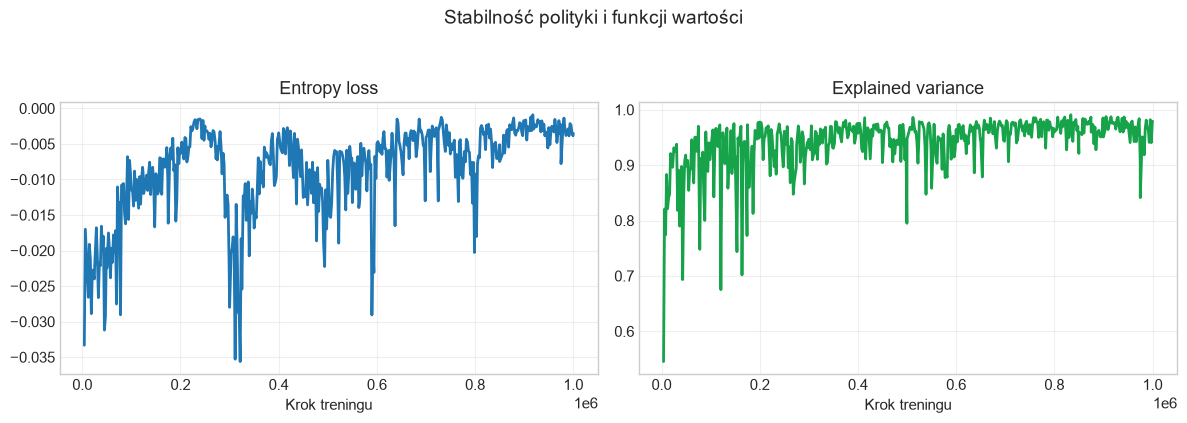

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_tag(axes[0], tb_series, "train/entropy_loss", "Entropy loss")
plot_tag(axes[1], tb_series, "train/explained_variance", "Explained variance", color="#16a34a")
fig.suptitle("Stabilność polityki i funkcji wartości", fontsize=14, y=1.05)
fig.tight_layout()
plt.show()

## 2. Ewaluacja okresowa (eval callback)

Plik `models/eval/evaluations.npz` — średnia nagroda co ~25k kroków treningu.

,krok,srednia_nagroda,srednia_dlugosc
0,25000,-0.010076,1801.0
1,50000,-0.315680,1801.0
2,75000,-0.211335,1801.0
3,100000,-0.139798,1801.0
4,125000,-0.185642,1801.0
5,150000,0.026448,1801.0
6,175000,-0.116877,1801.0
7,200000,-0.154471,1801.0
8,225000,-0.158060,1801.0
9,250000,-0.103401,1801.0


Najlepsza średnia nagroda: 0.1288 @ krok 650,000


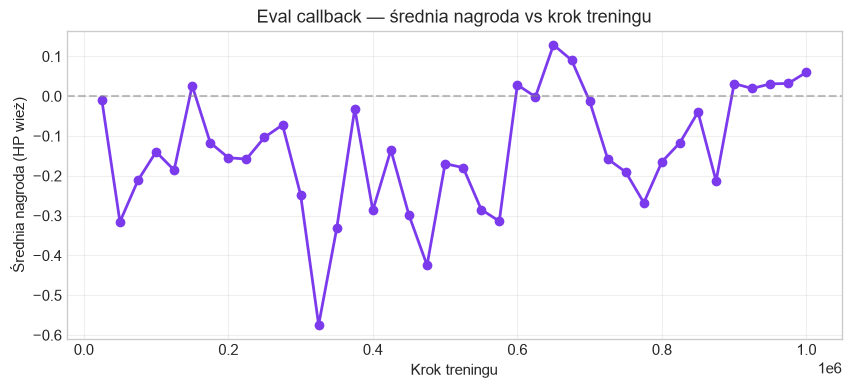

In [5]:
eval_data = load_eval_npz(EVAL_DIR)

if eval_data is None:
    print("Brak evaluations.npz — pojawi się po dłuższym treningu (eval co ~25k kroków).")
else:
    df_eval = pd.DataFrame({
        "krok": eval_data["timesteps"],
        "srednia_nagroda": eval_data["results"],
        "srednia_dlugosc": eval_data["ep_lengths"],
    })
    display(df_eval)

    best_idx = int(np.argmax(eval_data["results"]))
    print(
        f"Najlepsza średnia nagroda: {eval_data['results'][best_idx]:.4f} "
        f"@ krok {eval_data['timesteps'][best_idx]:,}"
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(eval_data["timesteps"], eval_data["results"], marker="o", linewidth=2, color="#7c3aed")
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_title("Eval callback — średnia nagroda vs krok treningu")
    ax.set_xlabel("Krok treningu")
    ax.set_ylabel("Średnia nagroda (HP wież)")
    ax.grid(True, alpha=0.3)
    plt.show()

## 3. Mecze na żywo — PPO vs LogicAgent

Porównanie zapisanych modeli `.zip` oraz losowego baseline'u (RL bez wag).

In [6]:
models = discover_models(str(DEFAULT_BEST_PATH) if DEFAULT_BEST_PATH.is_file() else None)
models = [m for m in models if "Checkpoint:" not in m[0]]

live_results = []
print("Ewaluacja losowego baseline (PPO bez modelu)...")
live_results.append(evaluate_random_baseline(episodes=EPISODES, seed=SEED))

for label, path in models:
    print(f"Ewaluacja: {label}...")
    live_results.append(evaluate_saved_model(label, path, episodes=EPISODES, seed=SEED))

rows = []
for r in live_results:
    rows.append({
        "model": r.label,
        "istnieje": r.exists,
        "mecze": r.episodes,
        "wygrane": r.wins,
        "przegrane": r.losses,
        "remisy": r.draws,
        "win_rate_%": round(100 * r.win_rate, 1),
        "srednia_nagroda": round(r.mean_reward, 4),
        "srednie_ticki": round(r.mean_length, 0),
        "blad": r.error,
    })

df_live = pd.DataFrame(rows)
display(df_live)

Ewaluacja losowego baseline (PPO bez modelu)...
Ewaluacja: Wybrany...
Ewaluacja: Finalny...
Ewaluacja: Eval callback...


,model,istnieje,mecze,wygrane,przegrane,remisy,win_rate_%,srednia_nagroda,srednie_ticki,blad
0,Losowy agent (baseline),True,30,14,16,0,46.7,-0.0560,1801.0,None
1,Wybrany,True,30,2,28,0,6.7,-0.2006,1794.0,None
2,Finalny,True,30,21,9,0,70.0,0.0649,1801.0,None
3,Eval callback,True,30,2,28,0,6.7,-0.2006,1794.0,None


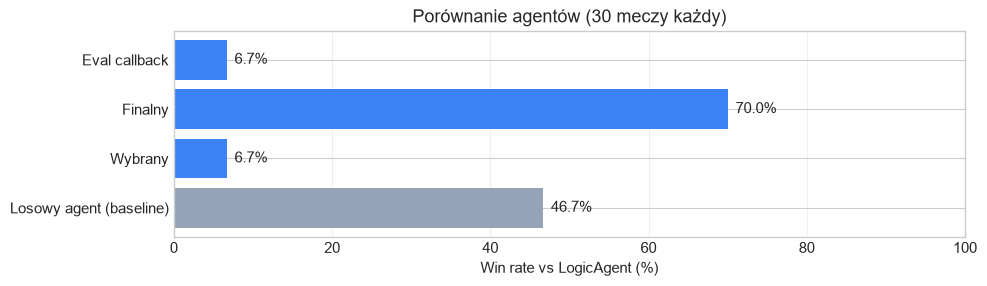

In [7]:
trained = [r for r in live_results if r.exists and not r.error]
if trained:
    fig, ax = plt.subplots(figsize=(10, max(3, 0.5 * len(trained))))
    labels = [r.label for r in trained]
    rates = [100 * r.win_rate for r in trained]
    colors = ["#94a3b8" if "Losowy" in l else "#3b82f6" for l in labels]
    bars = ax.barh(labels, rates, color=colors)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Win rate vs LogicAgent (%)")
    ax.set_title(f"Porównanie agentów ({EPISODES} meczy każdy)")
    for bar, rate in zip(bars, rates):
        ax.text(rate + 1, bar.get_y() + bar.get_height() / 2, f"{rate:.1f}%", va="center")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Brak wyników live-eval.")

## 4. LogicAgent vs RandomBot

Bot regułowy (P0) gra przeciw losowemu przeciwnikowi (P1) — benchmark jakości reguł.

In [8]:
print(f"Symulacja {LOGIC_EPISODES} meczy LogicAgent vs RandomBot...")
logic_vs_random = evaluate_logic_vs_random(episodes=LOGIC_EPISODES, seed=SEED)

logic_summary = pd.DataFrame([{
    "mecze": logic_vs_random.episodes,
    "wygrane_logic_P0": logic_vs_random.wins,
    "wygrane_random_P1": logic_vs_random.losses,
    "remisy": logic_vs_random.draws,
    "win_rate_logic_%": round(100 * logic_vs_random.win_rate, 1),
    "srednie_ticki": round(logic_vs_random.mean_length, 0),
}])
display(logic_summary)

Symulacja 50 meczy LogicAgent vs RandomBot...


,mecze,wygrane_logic_P0,wygrane_random_P1,remisy,win_rate_logic_%,srednie_ticki
0,50,50,0,0,100.0,1051.0


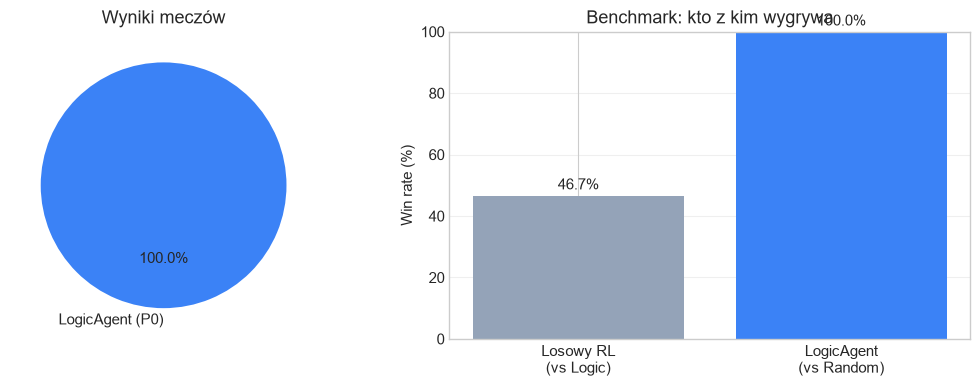

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

labels_pie = ["LogicAgent (P0)", "RandomBot (P1)", "Remis"]
sizes = [logic_vs_random.wins, logic_vs_random.losses, logic_vs_random.draws]
colors_pie = ["#3b82f6", "#ef4444", "#a3a3a3"]
axes[0].pie(
    [s for s in sizes if s > 0] or [1],
    labels=[l for l, s in zip(labels_pie, sizes) if s > 0] or ["brak danych"],
    colors=[c for c, s in zip(colors_pie, sizes) if s > 0] or ["#ccc"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[0].set_title("Wyniki meczów")

compare_labels = ["Losowy RL\n(vs Logic)", "LogicAgent\n(vs Random)"]
random_rl = next((r for r in live_results if "Losowy" in r.label), None)
compare_rates = [
    100 * random_rl.win_rate if random_rl else 0,
    100 * logic_vs_random.win_rate,
]
bars = axes[1].bar(compare_labels, compare_rates, color=["#94a3b8", "#3b82f6"])
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("Win rate (%)")
axes[1].set_title("Benchmark: kto z kim wygrywa")
for bar, rate in zip(bars, compare_rates):
    axes[1].text(bar.get_x() + bar.get_width() / 2, rate + 2, f"{rate:.1f}%", ha="center")
axes[1].grid(True, axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

## 5. Podsumowanie

Automatyczna interpretacja wyników.

In [10]:
trained_models = [
    r for r in live_results
    if r.exists and not r.error and "Losowy" not in r.label
]

if trained_models:
    best = max(trained_models, key=lambda r: r.win_rate)
    print(f"Najlepszy model PPO: {best.label}")
    print(f"  Win rate vs LogicAgent: {100 * best.win_rate:.1f}% ({best.episodes} meczy)")
    print(f"  Średnia nagroda: {best.mean_reward:.4f}")
else:
    print("Brak wytrenowanych modeli — uruchom: python train.py")

random_rl = next((r for r in live_results if "Losowy" in r.label), None)
if random_rl:
    print(f"\nLosowy RL vs LogicAgent: {100 * random_rl.win_rate:.1f}%")

print(
    f"\nLogicAgent vs RandomBot: {100 * logic_vs_random.win_rate:.1f}% "
    f"({logic_vs_random.wins}/{logic_vs_random.episodes} wygranych)"
)

if trained_models:
    best = max(trained_models, key=lambda r: r.win_rate)
    if best.win_rate >= 0.55:
        print("\n→ PPO stabilnie bije LogicAgent — dobry postęp.")
    elif best.win_rate >= 0.45:
        print("\n→ Poziom wyrównany — kontynuuj trening (więcej kroków).")
    else:
        print("\n→ PPO słabszy od LogicAgent — potrzebny dłuższy trening / tuning.")

if logic_vs_random.win_rate >= 0.7:
    print("→ LogicAgent mocno dominuje losowego bota — reguły działają dobrze.")
elif logic_vs_random.win_rate >= 0.5:
    print("→ LogicAgent wygrywa z RandomBotem, ale z marginesem.")
else:
    print("→ LogicAgent nie dominuje losowego bota — warto poprawić reguły.")

Najlepszy model PPO: Finalny
  Win rate vs LogicAgent: 70.0% (30 meczy)
  Średnia nagroda: 0.0649

Losowy RL vs LogicAgent: 46.7%

LogicAgent vs RandomBot: 100.0% (50/50 wygranych)

→ PPO stabilnie bije LogicAgent — dobry postęp.
→ LogicAgent mocno dominuje losowego bota — reguły działają dobrze.
